# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Vini Emeralda
- **Email:** vini.emerald617@gmail.com
- **ID Dicoding:** CDCC200D6X1774

## Menentukan Pertanyaan Bisnis

#### Deskripsi Data
Dataset `Air-Quality` merupakan kumpulan data menggambarkan pemantauan kualitas udara di lokasi terkontrol di Tiongkok. Dataset ini mencakup data polutan udara per jam dari 12 lokasi pemantauan kualitas udara yang dikendalikan secara nasional. Data kualitas udara berasal dari Beijing Municipal Environmental Monitoring Center. Data meteorologi di setiap lokasi pemantauan kualitas udara dicocokkan dengan stasiun cuaca terdekat dari China Meteorological Administration. Periode waktunya dari 1 Maret 2013 hingga 28 Februari 2017.

#### Keterangan Kolom
* No: row number
* year: year of data in this row 
* month: month of data in this row 
* day: day of data in this row 
* hour: hour of data in this row 
* PM2.5: PM2.5 concentration (ug/m^3)
* PM10: PM10 concentration (ug/m^3)
* SO2: SO2 concentration (ug/m^3)
* NO2: NO2 concentration (ug/m^3)
* CO: CO concentration (ug/m^3)
* O3: O3 concentration (ug/m^3)
* TEMP: temperature (degree Celsius) 
* PRES: pressure (hPa)
* DEWP: dew point temperature (degree Celsius)
* RAIN: precipitation (mm)
* wd: wind direction
* WSPM: wind speed (m/s)
* station: name of the air-quality monitoring site

#### Sumber
- https://www.kaggle.com/datasets/sid321axn/beijing-multisite-airquality-data-set
- https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data
- https://github.com/marceloreis/HTI

#### Pertanyaan Bisnis
- Bagaimana kondisi kualitas udara di Beijing selama 2013-2017 secara keseluruhan?
- Apakah ada perbedaan kualitas udara antarstasiun yang mencolok?
- Apakah kondisi cuaca dan musim tertentu berkaitan dengan tinggi-rendahnya polutan?
- Apakah ada pola musiman pada variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import os

# visualisasi data
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# analisis geospatial
import folium
import time
from geopy.geocoders import Nominatim
from branca.element import Template, MacroElement

## Data Wrangling

### Gathering Data

Baca semua data yang ada di folder Air Quality Dataset dan simpan dalam dictionary yang berisi dataFrame masing-masing .csv dengan format nama df_namaStasiun.

In [2]:
path = "data/Air-quality-dataset/PRSA_Data_20130301-20170228/"
dfs = {}

for file in os.listdir(path):
    if file.endswith(".csv"):
        wilayah = file.split("_")[2]  # ambil nama wilayah
        df_name = f"df_{wilayah.lower()}"
        
        file_path = os.path.join(path, file)
        dfs[df_name] = pd.read_csv(file_path)

dfs.keys()

dict_keys(['df_aotizhongxin', 'df_changping', 'df_dingling', 'df_dongsi', 'df_guanyuan', 'df_gucheng', 'df_huairou', 'df_nongzhanguan', 'df_shunyi', 'df_tiantan', 'df_wanliu', 'df_wanshouxigong'])

In [3]:
dfs["df_aotizhongxin"].head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


Melihat struktur kolom semua dataFrame.

In [4]:
df_column_names = pd.DataFrame({
    name: list(df.columns)
    for name, df in dfs.items()
}).T

df_column_names.columns = [f"col_{i}" for i in range(df_column_names.shape[1])]
df_column_names

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17
df_aotizhongxin,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_changping,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_dingling,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_dongsi,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_guanyuan,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_gucheng,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_huairou,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_nongzhanguan,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_shunyi,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
df_tiantan,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station


Kolom semua dataFrame sama sehingga dapat dilakukan merge row dengan `concat()`. Namun, masing-masing data frame perlu melalui assessing dan cleaning data terlebih dahulu untuk memastikan semua dataFrame siap digabungkan.

### Assessing Data

#### df_aotizhongxin

Melihat overview dan struktur data.

In [5]:
df = dfs["df_aotizhongxin"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              925            2.64
PM10               718            2.05
SO2                935            2.67
NO2               1023            2.92
CO                1776            5.07
O3                1719            4.90
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                  81            0.23
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


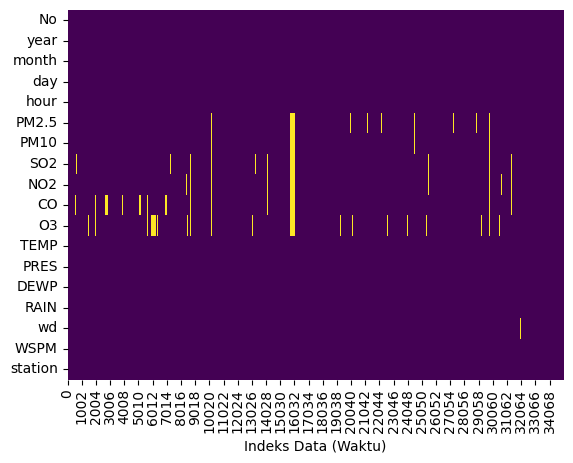

In [7]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Missing value terdapat pada: <br>
- `PM2.5` sebanyak 925 missing values.
- `PM10` sebanyak 718 missing values.
- `SO2` sebanyak 935 missing values.
- `NO2` sebanyak 1023 missing values.
- `CO2` sebanyak 1776 missing values.
- `O3` sebanyak 1719 missing values.
- `TEMP` sebanyak 20 missing values.
- `PRES` sebanyak 20 missing values.
- `DEWP` sebanyak 20 missing values.
- `RAIN` sebanyak 20 missing values.
- `wd` sebanyak 81 missing values.
- `WSMP` sebanyak 14 missing values.

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [8]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [9]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,34983,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5140,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,NaN,1.708496,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,NaN,1.204071,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,NaN,2.200000,NaN


In [10]:
df["station"].value_counts()

station
Aotizhongxin    35064
Name: count, dtype: int64

Stasiun pada df_aotizhongxin konsisten pada wilayah aotizhongtin dan tidak tercampur dengan wilayah lain.

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_changping

In [11]:
df = dfs["df_changping"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              774            2.21
PM10               582            1.66
SO2                628            1.79
NO2                667            1.90
CO                1521            4.34
O3                 604            1.72
TEMP                53            0.15
PRES                50            0.14
DEWP                53            0.15
RAIN                51            0.15
wd                 140            0.40
WSPM                43            0.12
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


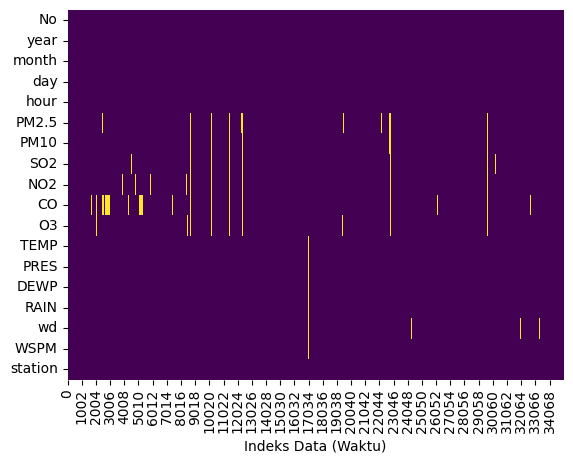

In [13]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Missing value terdapat pada: <br>
- `PM2.5` sebanyak 774 missing values.
- `PM10` sebanyak 582 missing values.
- `SO2` sebanyak 628 missing values.
- `NO2` sebanyak 667 missing values.
- `CO2` sebanyak 1521 missing values.
- `O3` sebanyak 604 missing values.
- `TEMP` sebanyak 53 missing values.
- `PRES` sebanyak 50 missing values.
- `DEWP` sebanyak 53 missing values.
- `RAIN` sebanyak 51 missing values.
- `wd` sebanyak 140 missing values.
- `WSMP` sebanyak 43 missing values.

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [14]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [15]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Changping
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


In [16]:
df["station"].value_counts()

station
Changping    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_dingling

In [17]:
df = dfs["df_dingling"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              779            2.22
PM10               656            1.87
SO2                730            2.08
NO2               1234            3.52
CO                2012            5.74
O3                1214            3.46
TEMP                53            0.15
PRES                50            0.14
DEWP                53            0.15
RAIN                51            0.15
wd                 140            0.40
WSPM                43            0.12
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


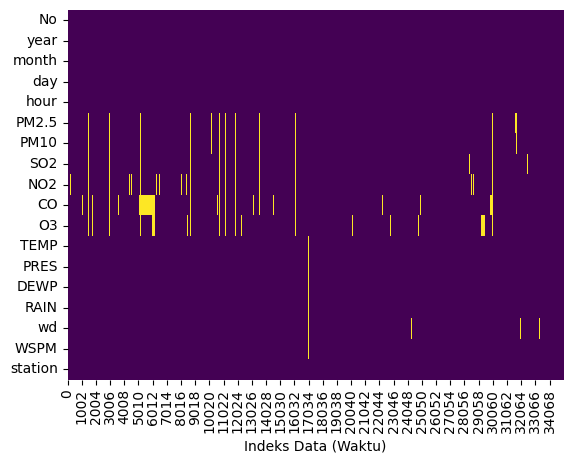

In [19]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning. Namun jika melihat overview data, missing value `NO2` berada pada awal periode sehingga perlu berhati-hati jika menggunakan interpolasi.

In [20]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [21]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Dingling
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


In [22]:
df["station"].value_counts()

station
Dingling    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_dongsi

In [23]:
df = dfs["df_dongsi"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              750            2.14
PM10               553            1.58
SO2                663            1.89
NO2               1601            4.57
CO                3197            9.12
O3                 664            1.89
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                  78            0.22
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


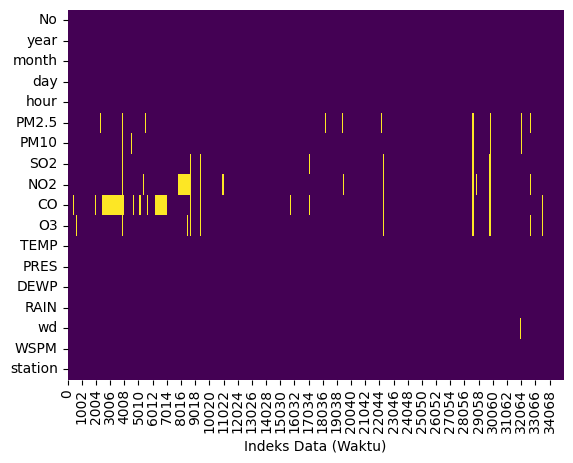

In [25]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [26]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [27]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Dongsi
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [28]:
df["station"].value_counts()

station
Dongsi    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_guanyuan

In [29]:
df = dfs["df_guanyuan"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              616            1.76
PM10               429            1.22
SO2                474            1.35
NO2                659            1.88
CO                1753            5.00
O3                1173            3.35
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                  81            0.23
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


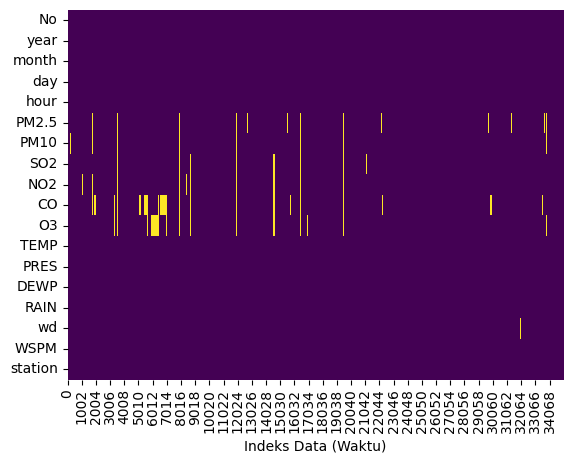

In [31]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [32]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [33]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,34983,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Guanyuan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5140,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,NaN,1.708496,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,NaN,1.204071,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,NaN,2.200000,NaN


In [34]:
df["station"].value_counts()

station
Guanyuan    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_gucheng

In [35]:
df = dfs["df_gucheng"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              646            1.84
PM10               381            1.09
SO2                507            1.45
NO2                668            1.91
CO                1401            4.00
O3                 729            2.08
TEMP                51            0.15
PRES                50            0.14
DEWP                51            0.15
RAIN                43            0.12
wd                 159            0.45
WSPM                42            0.12
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


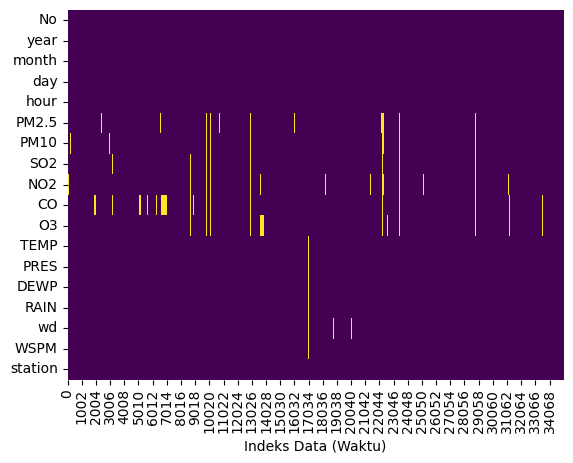

In [37]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning. Namun jika melihat overview data, missing value `NO2` berada pada awal periode sehingga perlu berhati-hati jika menggunakan interpolasi.

In [38]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [39]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,34905,35022.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Gucheng
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3949,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,NaN,1.343310,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,NaN,1.151064,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,NaN,0.600000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,NaN,1.000000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,NaN,1.800000,NaN


In [40]:
df["station"].value_counts()

station
Gucheng    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_huairou

In [41]:
df = dfs["df_huairou"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34111 non-null  float64
 6   PM10     34287 non-null  float64
 7   SO2      34084 non-null  float64
 8   NO2      33425 non-null  float64
 9   CO       33642 non-null  float64
 10  O3       33913 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35011 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35009 non-null  float64
 15  wd       34762 non-null  object 
 16  WSPM     35015 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              953            2.72
PM10               777            2.22
SO2                980            2.79
NO2               1639            4.67
CO                1422            4.06
O3                1151            3.28
TEMP                51            0.15
PRES                53            0.15
DEWP                53            0.15
RAIN                55            0.16
wd                 302            0.86
WSPM                49            0.14
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


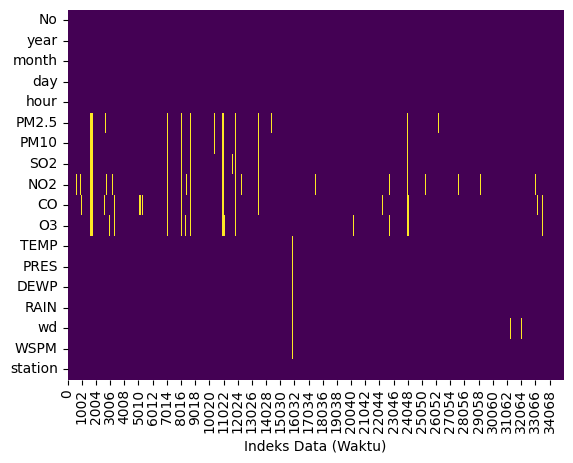

In [43]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [44]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [45]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,34762,35015.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NW,NaN,Huairou
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4943,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,NaN,1.652021,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,NaN,1.199143,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,NaN,1.300000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,NaN,2.000000,NaN


In [46]:
df["station"].value_counts()

station
Huairou    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_nongzhanguan

In [47]:
df = dfs["df_nongzhanguan"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              628            1.79
PM10               440            1.25
SO2                446            1.27
NO2                692            1.97
CO                1206            3.44
O3                 506            1.44
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                  78            0.22
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


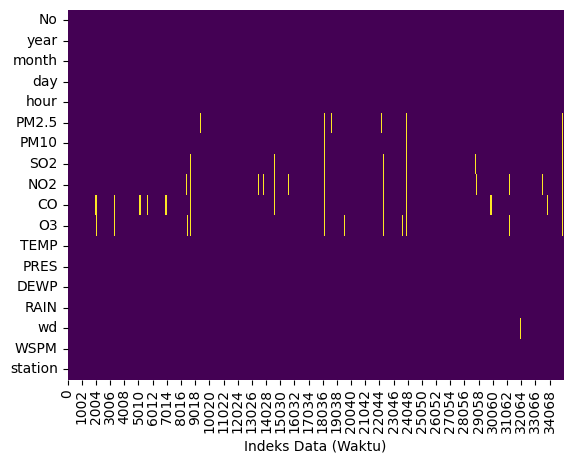

In [49]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [50]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [51]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Nongzhanguan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [52]:
df["station"].value_counts()

station
Nongzhanguan    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_shunyi

In [53]:
df = dfs["df_shunyi"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34151 non-null  float64
 6   PM10     34516 non-null  float64
 7   SO2      33768 non-null  float64
 8   NO2      33699 non-null  float64
 9   CO       32886 non-null  float64
 10  O3       33575 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35013 non-null  float64
 13  DEWP     35010 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34581 non-null  object 
 16  WSPM     35020 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              913            2.60
PM10               548            1.56
SO2               1296            3.70
NO2               1365            3.89
CO                2178            6.21
O3                1489            4.25
TEMP                51            0.15
PRES                51            0.15
DEWP                54            0.15
RAIN                51            0.15
wd                 483            1.38
WSPM                44            0.13
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


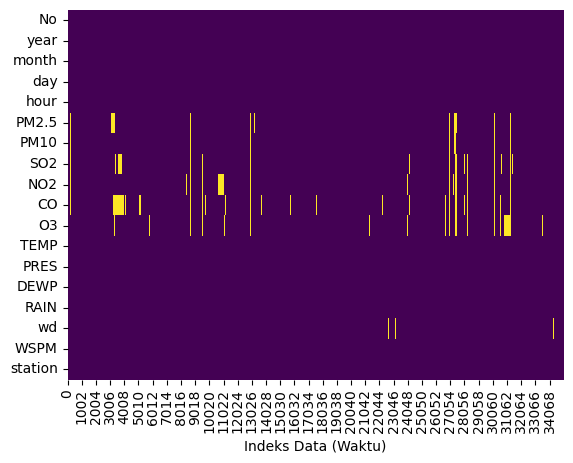

In [55]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [56]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [57]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34151.000000,34516.000000,33768.000000,33699.000000,32886.000000,33575.000000,35013.000000,35013.000000,35010.000000,35013.000000,34581,35020.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNE,NaN,Shunyi
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4540,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321,13.387969,1013.061938,2.465036,0.061094,NaN,1.807533,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.231739,89.143718,19.572068,30.996828,1156.374102,54.873726,11.483588,10.177339,13.726622,0.761668,NaN,1.287817,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,988.000000,-36.000000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,19.000000,31.000000,2.000000,19.000000,400.000000,10.000000,3.000000,1004.700000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,77.000000,5.000000,37.000000,800.000000,43.000000,14.400000,1012.700000,3.100000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,138.000000,17.000000,62.000000,1500.000000,77.000000,23.200000,1021.000000,15.100000,0.000000,NaN,2.300000,NaN


In [58]:
df["station"].value_counts()

station
Shunyi    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_tiantan

In [59]:
df = dfs["df_tiantan"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              677            1.93
PM10               597            1.70
SO2               1118            3.19
NO2                744            2.12
CO                1126            3.21
O3                 843            2.40
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                  78            0.22
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


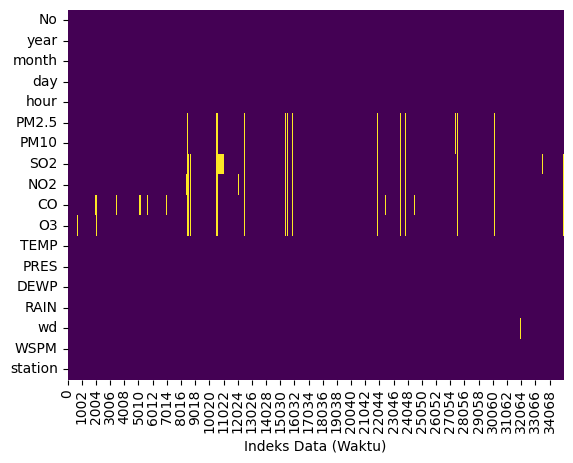

In [61]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [62]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [63]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Tiantan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [64]:
df["station"].value_counts()

station
Tiantan    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_wanliu

In [65]:
df = dfs["df_wanliu"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              382            1.09
PM10               284            0.81
SO2                575            1.64
NO2               1070            3.05
CO                1812            5.17
O3                2107            6.01
TEMP                20            0.06
PRES                20            0.06
DEWP                20            0.06
RAIN                20            0.06
wd                 123            0.35
WSPM                14            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


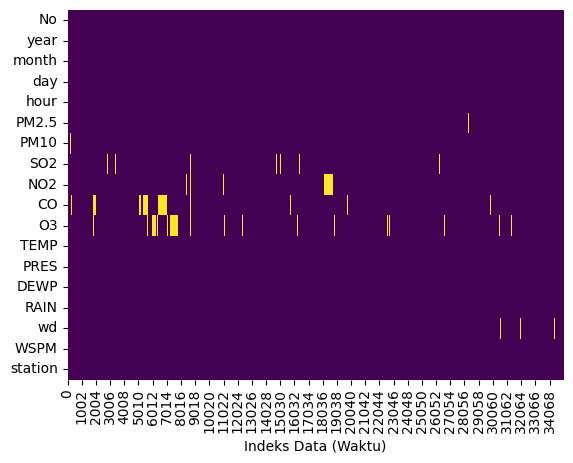

In [67]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [68]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [69]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34682.000000,34780.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35044.000000,35044.000000,34941,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Wanliu
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6703,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614,13.428865,1011.097536,3.266588,0.068263,NaN,1.501215,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.905568,92.795065,22.609648,37.996088,1268.114331,55.111740,11.346931,10.355247,13.678060,0.896726,NaN,1.104472,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.642400,100.000000,0.214200,-15.800000,985.900000,-34.900000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,4.000000,36.000000,500.000000,4.000000,3.200000,1002.500000,-8.100000,0.000000,NaN,0.800000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,88.000000,10.000000,60.000000,900.000000,32.000000,14.300000,1010.800000,4.000000,0.000000,NaN,1.200000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,153.000000,23.000000,88.000000,1600.000000,73.000000,22.900000,1019.400000,15.800000,0.000000,NaN,2.000000,NaN


In [70]:
df["station"].value_counts()

station
Wanliu    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

#### df_wanshouxigong

In [71]:
df = dfs["df_wanshouxigong"]
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34368 non-null  float64
 6   PM10     34580 non-null  float64
 7   SO2      34395 non-null  float64
 8   NO2      34310 non-null  float64
 9   CO       33767 non-null  float64
 10  O3       33986 non-null  float64
 11  TEMP     35045 non-null  float64
 12  PRES     35045 non-null  float64
 13  DEWP     35045 non-null  float64
 14  RAIN     35045 non-null  float64
 15  wd       34985 non-null  object 
 16  WSPM     35051 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Tidak ada masalah pada tipe data (Dtype), tetapi terdapat missing value pada kolom `PM2.5`, `PM10`, `SO2`, `NO2`, `CO2`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, dan `WSMP`.

         Jumlah Hilang  Persentase (%)
No                   0            0.00
year                 0            0.00
month                0            0.00
day                  0            0.00
hour                 0            0.00
PM2.5              696            1.98
PM10               484            1.38
SO2                669            1.91
NO2                754            2.15
CO                1297            3.70
O3                1078            3.07
TEMP                19            0.05
PRES                19            0.05
DEWP                19            0.05
RAIN                19            0.05
wd                  79            0.23
WSPM                13            0.04
station              0            0.00
Axes(0.125,0.11;0.775x0.77)


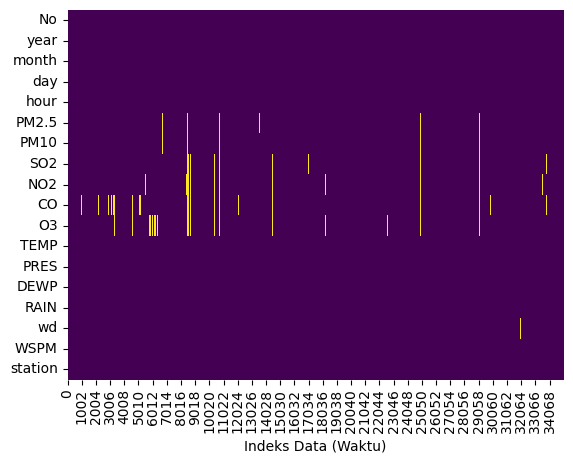

In [73]:
print(pd.concat([df.isnull().sum(),
           df.isnull().mean() * 100],
          axis=1, keys=['Jumlah Hilang', 'Persentase (%)']).round(2)
)

# visualisasi
print(sns.heatmap(df.isnull().T, cbar=False, cmap='viridis'))
plt.xlabel('Indeks Data (Waktu)')
plt.show()

Persentase missing value masing-masing kolom relatif kecil sehingga dapat ditangani dengan imputasi berbasis waktu pada tahap data cleaning.

In [74]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


Tidak ada baris duplikasi.

In [75]:
df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,34985,35051.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Wanshouxigong
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3568,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,NaN,1.745314,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,NaN,1.206355,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,NaN,2.300000,NaN


In [76]:
df["station"].value_counts()

station
Wanshouxigong    35064
Name: count, dtype: int64

**Overall Insight:**
- Tidak ada masalah pada tipe data
- Ada beberapa kolom yang memiliki missing values.
- Tidak terdapat data yang terduplikat.
- Data sudah konsisten.

### Cleaning Data

Karena semua dataFrame memiliki masalah yang sama, yaitu missing values, maka akan dilakukan penanganan missing values dengan looping semua dataFrame. Penanganan yang dilakukan yaitu imputasi berbasis waktu karena dataset merupakan data time series (runtun waktu). Imputasi berbasis waktu yang digunakan adalah: <br>
- interpolate untuk data numerik (tipe data int dan float)
- forward fill untuk data kategorik (tipe data object)

In [77]:
columns = next(iter(dfs.values())).columns
df_missing = pd.DataFrame({'column_name': columns})

for name, df in dfs.items():
    df_missing[name] = df.isna().sum().values

df_missing.set_index('column_name', inplace=True)
df_missing

,df_aotizhongxin,df_changping,df_dingling,df_dongsi,df_guanyuan,df_gucheng,df_huairou,df_nongzhanguan,df_shunyi,df_tiantan,df_wanliu,df_wanshouxigong
column_name,,,,,,,,,,,,
No,0,0,0,0,0,0,0,0,0,0,0,0
year,0,0,0,0,0,0,0,0,0,0,0,0
month,0,0,0,0,0,0,0,0,0,0,0,0
day,0,0,0,0,0,0,0,0,0,0,0,0
hour,0,0,0,0,0,0,0,0,0,0,0,0
PM2.5,925,774,779,750,616,646,953,628,913,677,382,696
PM10,718,582,656,553,429,381,777,440,548,597,284,484
SO2,935,628,730,663,474,507,980,446,1296,1118,575,669
NO2,1023,667,1234,1601,659,668,1639,692,1365,744,1070,754


In [78]:
dfs_clean = {}
for df in dfs.keys():
    num_cols = dfs[df].select_dtypes(exclude="object").interpolate()
    cat_cols = dfs[df].select_dtypes(include="object").ffill()
    dfs_clean[df] = pd.concat([num_cols, cat_cols],axis=1)

In [79]:
columns = next(iter(dfs_clean.values())).columns
df_missing = pd.DataFrame({'column_name': columns})

for name, df in dfs_clean.items():
    df_missing[name] = df.isna().sum().values

df_missing.set_index('column_name', inplace=True)
df_missing

,df_aotizhongxin,df_changping,df_dingling,df_dongsi,df_guanyuan,df_gucheng,df_huairou,df_nongzhanguan,df_shunyi,df_tiantan,df_wanliu,df_wanshouxigong
column_name,,,,,,,,,,,,
No,0,0,0,0,0,0,0,0,0,0,0,0
year,0,0,0,0,0,0,0,0,0,0,0,0
month,0,0,0,0,0,0,0,0,0,0,0,0
day,0,0,0,0,0,0,0,0,0,0,0,0
hour,0,0,0,0,0,0,0,0,0,0,0,0
PM2.5,0,0,0,0,0,0,0,0,0,0,0,0
PM10,0,0,0,0,0,0,0,0,0,0,0,0
SO2,0,0,0,0,0,0,0,0,0,0,0,0
NO2,0,0,2,0,0,20,0,0,0,0,0,0


Seperti yang sudah dideskripsikan pada bagian df_dingling dan df_gucheng, imputasi dengan interpolasi tidak bisa dilakukan karena terdapat missing value dengan posisi di ujung, karena interpolate() hanya mampu menangani missing di tengah. Oleh karena itu, dilakukan imputasi lanjutan dengan ffill/bfill untuk menangani sisa missing value di ujung. Sebelum itu, perlu dicek dulu apakah missing value berada di awal, di akhir, atau di awal dan di akhir untuk kedua dataFrame yang masih ada missing value.

In [80]:
df_cek = dfs_clean["df_gucheng"]
df_cek[df_cek['NO2'].isna()].head(100)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,4.4,NW,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,4.0,NW,Gucheng
2,3,2013,3,1,2,5.0,18.0,5.5,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,4.6,WNW,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,650.0,62.5,-1.0,1022.7,-21.2,0.0,2.8,W,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,3.6,WNW,Gucheng
5,6,2013,3,1,5,4.0,11.0,3.0,NaN,700.0,87.0,-1.8,1023.6,-21.9,0.0,1.2,E,Gucheng
6,7,2013,3,1,6,3.0,6.0,3.0,NaN,700.0,92.0,-2.6,1024.3,-20.4,0.0,1.2,ENE,Gucheng
7,8,2013,3,1,7,5.0,5.0,3.0,NaN,800.0,86.0,-0.9,1025.6,-20.5,0.0,1.1,ENE,Gucheng
8,9,2013,3,1,8,5.0,9.0,5.0,NaN,900.0,81.0,0.1,1026.1,-20.3,0.0,3.0,ENE,Gucheng
9,10,2013,3,1,9,4.0,10.0,6.0,NaN,900.0,82.0,1.1,1026.1,-20.6,0.0,2.8,NE,Gucheng


In [81]:
df_cek2 = dfs_clean["df_dingling"]
df_cek2[df_cek2['NO2'].isna()].head(100)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,0.5,E,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,0.7,ENE,Dingling


Missing value berada di awal periode untuk kedua dataframe sehingga imputasi dilakukan dengan backward fill (bfill).

In [82]:
for df in dfs_clean.keys():
    num_cols = dfs_clean[df].select_dtypes(exclude="object").bfill()
    cat_cols = dfs_clean[df].select_dtypes(include="object")
    dfs_clean[df] = pd.concat([num_cols, cat_cols],axis=1)

columns = next(iter(dfs_clean.values())).columns
df_missing = pd.DataFrame({'column_name': columns})

for name, df in dfs_clean.items():
    df_missing[name] = df.isna().sum().values

df_missing.set_index('column_name', inplace=True)
df_missing

,df_aotizhongxin,df_changping,df_dingling,df_dongsi,df_guanyuan,df_gucheng,df_huairou,df_nongzhanguan,df_shunyi,df_tiantan,df_wanliu,df_wanshouxigong
column_name,,,,,,,,,,,,
No,0,0,0,0,0,0,0,0,0,0,0,0
year,0,0,0,0,0,0,0,0,0,0,0,0
month,0,0,0,0,0,0,0,0,0,0,0,0
day,0,0,0,0,0,0,0,0,0,0,0,0
hour,0,0,0,0,0,0,0,0,0,0,0,0
PM2.5,0,0,0,0,0,0,0,0,0,0,0,0
PM10,0,0,0,0,0,0,0,0,0,0,0,0
SO2,0,0,0,0,0,0,0,0,0,0,0,0
NO2,0,0,0,0,0,0,0,0,0,0,0,0


Karena semua masalah sudah diatasi dan data sudah bersih, maka semua dataFrame dapat di-merge row dengan concat().

In [83]:
df_cleaned = pd.concat(dfs_clean.values(), ignore_index=True)
df_cleaned.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,NNW,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,N,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,NNW,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,NW,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,N,Aotizhongxin


In [84]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    420768 non-null  float64
 6   PM10     420768 non-null  float64
 7   SO2      420768 non-null  float64
 8   NO2      420768 non-null  float64
 9   CO       420768 non-null  float64
 10  O3       420768 non-null  float64
 11  TEMP     420768 non-null  float64
 12  PRES     420768 non-null  float64
 13  DEWP     420768 non-null  float64
 14  RAIN     420768 non-null  float64
 15  WSPM     420768 non-null  float64
 16  wd       420768 non-null  object 
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


**Insight:**
- Semua missing value sudah ditangani dengan interpolasi dan backward fill untuk data numerik, forward fill untuk data kategorik.
- Data sudah bersih sehingga bisa disimpan dalam format .csv.

In [85]:
df_cleaned.to_csv("data/df_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

### Data Overview

In [86]:
df = pd.read_csv("data/df_cleaned.csv", index_col="No")
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
No,,,,,,,,,,,,,,,,,
1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,NNW,Aotizhongxin
2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,N,Aotizhongxin
3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,NNW,Aotizhongxin
4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,NW,Aotizhongxin
5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,N,Aotizhongxin


### Struktur Data

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 1 to 35064
Data columns (total 17 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   year     420768 non-null  int64  
 1   month    420768 non-null  int64  
 2   day      420768 non-null  int64  
 3   hour     420768 non-null  int64  
 4   PM2.5    420768 non-null  float64
 5   PM10     420768 non-null  float64
 6   SO2      420768 non-null  float64
 7   NO2      420768 non-null  float64
 8   CO       420768 non-null  float64
 9   O3       420768 non-null  float64
 10  TEMP     420768 non-null  float64
 11  PRES     420768 non-null  float64
 12  DEWP     420768 non-null  float64
 13  RAIN     420768 non-null  float64
 14  WSPM     420768 non-null  float64
 15  wd       420768 non-null  object 
 16  station  420768 non-null  object 
dtypes: float64(11), int64(4), object(2)
memory usage: 57.8+ MB


**Insight:** <br>
Terdapat 16 kolom dan 420768 baris. Kolom-kolom tersebut bisa dibagi menjadi beberapa kelompok: <br>
- Kelompok identitas: station
- Kelompok waktu: year, month, day, hout
- Kelompok polutan: PM2.5, PM10, SO2, NO2, CO, O3
- Kelompok cuaca: TEMP, PRES, DEWP, RAIN, WSPM, wd

Variabel wd dan station merupakan data kategorik yang ditunjukkan dengan Dtype object. Sementara variabel lainnya merupakan data numerik dengan tipe data int dan float.

### Identifikasi Variabel

In [88]:
df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,2014.662560,6.522930,15.729637,11.500000,79.839718,104.910268,15.913090,50.599018,1235.682649,57.237872,13.531692,1010.753337,2.482421,0.064428,1.730034
std,1.177198,3.448707,8.800102,6.922195,80.950217,92.431422,21.896609,35.171921,1161.790893,57.135195,11.437867,10.474302,13.797675,0.820638,1.246674
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Insight:**
- PM2.5 berkisar pada rentang 2-999 dengan kuartal 1 = 20, median = 55, dan kuartal 3 = 111. Hal ini menunjukkan distribusi condong ke kanan (right-skewed). Ini juga digukung dengan standar deviasi yang lebar yaitu 80.95 yang menunjukkan variabilitas tinggi, dan rata-rata 79.83 yang berarti nilai rata-rata berada di sebelah kanan median.
- Pola PM2.5 juga ditemukan pada PM10, CO, dan O3.
- SO2 memiliki rentang 0.2856-500 dengan mean = 15.91 dan standar deviasi 21.89.
- NO2 memiliki rentang 1.0265-290 dengan mean = 50.59 dan standar deviasi 35.17.
- TEMP atau suhu udara terendah adalah -19.9 dan suhu tertinggi 41.6. Mean TEMP = 13.53 dan standar deviasinya = 11.43.
- PRES atau tekanan udara memiliki rentang 982.4-1042.8 dengan mean = 1010.75 dan standar deviasi = 10.47.
- DEWP memiliki rentang -43.4 hingga 29.1 dengan mean = 2.48 dan standar deviasi 13.79.
- RAIN memiliki rentang 0-72.5 dengan kuartal 1 sampai 3 bernilai 0, hal ini berarti data RAIN di Beijing pada periode waktu pengamatan didominasi nilai 0. Nilai mean untuk RAIN adalah 0.064 dengan standar deviasi 0.82.
- WSPM memiliki rentang 0-13.2 dengan mean = 1.73 dan standar deviasi = 1.24.

In [89]:
df.nunique()

year           5
month         12
day           31
hour          24
PM2.5       5704
PM10        4887
SO2         4946
NO2         8126
CO         10465
O3          8814
TEMP        2134
PRES         797
DEWP         788
RAIN         256
WSPM         200
wd            16
station       12
dtype: int64

In [90]:
df.station.value_counts()

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

Terdapat 12 stasiun dengan masing-masing stasiun berjumlah 35064. Kolom ini dapat digunakan untuk analisis spasial lebih lanjut.

In [91]:
df.wd.value_counts()

wd
NE     43653
ENE    34215
NW     32868
N      30979
E      29822
SW     28998
NNE    28330
NNW    25393
WNW    24478
ESE    24264
SSW    22606
SE     20211
WSW    20086
S      19444
SSE    17741
W      17680
Name: count, dtype: int64

Terdapat 16 wind direction/arah mata angin. Kolom ini dapat diproses dengan one hot encoding, namun jadinya akan menghasilkan 16 kolom baru. Ada pula cara lain dengan circular encoding, yaitu mengubah 16 kategori tersebut menjadi derajat (0-360), lalu dipecah menjadi komponen sin dan cos. Circular encoding lebih cocok untuk data arah yang bersifat siklik.

Namun, hal tersebut tidak akan dilakukan karena sulit diinterpretasikan jika kolom wd ingin digunakan dalam analisis korelasi. Oleh karena itu, dalam analisis korelasi tidak akan mengikutsertakan wd dan fokus ke variabel cuaca lainnya.

### Feature Engineering

#### Date (tanggal)

Untuk keperluan explanatory analysis, kolom date perlu dibuat dengan menggunakan nilai yang ada pada kolom year, month, dan day.

In [92]:
df.insert(0, 'date', pd.to_datetime(df[['year', 'month', 'day']]))
df.head()

,date,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
No,,,,,,,,,,,,,,,,,,
1,2013-03-01,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,NNW,Aotizhongxin
2,2013-03-01,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,N,Aotizhongxin
3,2013-03-01,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,NNW,Aotizhongxin
4,2013-03-01,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,NW,Aotizhongxin
5,2013-03-01,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,N,Aotizhongxin


In [93]:
df.to_csv("data/df_all.csv", index="No")

#### Agregasi Harian
Untuk keperluan explanatory analysis, akan dibuat dataFrame baru yang berupa agregasi harian dari df. Ini diperlukan untuk menjawab pertanyaan bisnis yang berkaitan dengan kualitas udara.

Untuk variabel polutan ('PM2.5', 'PM10', 'SO2', 'NO2', 'CO') dan variabel cuaca numerik ('TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM') mengambil nilai rata-rata hariannya. Untuk variabel kategorik ('wd', 'station') mengambil nilai modusnya. Khusus variabel O3, mengambil nilai maksimum rata-rata 8 jam dalam sehari. Hal ini sesuai dengan konsep perhitungan indeks kualitas udara yang akan dijelaskan di bagian berikutnya.

In [94]:
polutan_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO']
cuaca_cols   = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
kategori_cols = ['wd']
agg_dict = {}

def mode_func(x):
    return x.mode().iloc[0] if not x.mode().empty else None

# menggunakan mean untuk variabel polutan & cuaca
for col in polutan_cols + cuaca_cols:
    agg_dict[col] = 'mean'

# menggunakan modus untuk tipe kategorik
for col in kategori_cols:
    agg_dict[col] = mode_func

# agregasi harian
df_agregasi = df.groupby(['station','date']).agg(agg_dict).reset_index()

df = df.sort_values(['station', 'date'])
df['O3_8h_avg'] = df.groupby('station')['O3']\
                    .transform(lambda x: x.rolling(8, min_periods=8).mean())
o3_daily = df.groupby(['station', 'date'])['O3_8h_avg'].max().reset_index()
o3_daily.columns = ['station', 'date', 'O3']

df_agregasi = df_agregasi.merge(o3_daily, on=['station','date'], how='left')
df_agregasi['year']  = df_agregasi['date'].dt.year
df_agregasi['month'] = df_agregasi['date'].dt.month
df_agregasi['day']   = df_agregasi['date'].dt.day
df_agregasi.head()

,station,date,PM2.5,PM10,SO2,NO2,CO,TEMP,PRES,DEWP,RAIN,WSPM,wd,O3,year,month,day
0,Aotizhongxin,2013-03-01,7.125000,10.750000,11.708333,22.583333,429.166667,1.391667,1026.875000,-18.745833,0.0,3.254167,N,74.500,2013,3,1
1,Aotizhongxin,2013-03-02,30.750000,42.083333,36.625000,66.666667,824.916667,0.616667,1026.850000,-15.937500,0.0,1.479167,NE,52.625,2013,3,2
2,Aotizhongxin,2013-03-03,76.916667,120.541667,61.291667,81.000000,1620.625000,5.566667,1014.608333,-12.316667,0.0,1.658333,NNE,50.625,2013,3,3
3,Aotizhongxin,2013-03-04,22.708333,44.583333,22.854167,46.187500,606.250000,9.962500,1017.650000,-11.683333,0.0,2.404167,N,77.250,2013,3,4
4,Aotizhongxin,2013-03-05,148.875000,183.791667,93.875000,132.833333,2357.958333,6.291667,1010.900000,-7.525000,0.0,1.129167,NE,84.000,2013,3,5


#### AQI (air quality index)
Air Quality Index (AQI) adalah sistem untuk menerjemahkan pengukuran konsentrasi polutan yang terkadang membingungkan atau tidak intuitif, menjadi satu skala yang mudah dipahami dengan jelas mewakili risiko kesehatan yang ditimbulkan oleh polusi udara sekitar. Rumus indeks ini mempertimbangkan 6 polutan utama, yaitu PM2.5, PM10, karbon monoksida, sulfur dioksida, nitrogen dioksida, dan ozon. China dan Amerika memiliki dua sistem yang paling banyak digunakan. Standar China akan digunakan untuk analisis ini karena dataset berlokasi di wilayah-wilayah Tiongkok. AQI China sendiri didasarkan pada protokol pelaporan resmi Cina tetapi menggunakan rata-rata per jam untuk refleksi yang lebih segera dari tingkat polusi udara.

**China AQI Level**: <br>
Excellent            -> 0–50    <br>
Good                 -> 51–100  <br>
Lightly Polluted     -> 101–150 <br>
Moderately Polluted  -> 151–200 <br>
Heavily Polluted     -> 201–300 <br>
Severely Polluted    -> 301+    <br>

**Rumus AQI**:
$$
I_P = \frac{I_{high}-I_{low}}{BP_{high}-BP_{low}} * (C_P-BP_{low}) + I_{low}
$$

$$AQI=Max(I_{PM2.5}, I_{PM10}, I_{SO2}, I_{NO2}, I_{CO}, I_{O3})$$

Breakpoints masing-masing variabel polutan didasarkan pada https://aqihub.info/indices/china yang bersumber dari Technical Regulation on Ambient Air Quality Index (on trial).

**Sumber**: <br>
- https://www.iqair.com/id/support/knowledge-base/what-is-the-difference-between-china-us-aqi
- https://aqihub.info/indices/china

In [95]:
# mendefinisikan breakpoints
bp_pm25 = [
    (0, 35, 0, 50),
    (35, 75, 50, 100),
    (75, 115, 100, 150),
    (115, 150, 150, 200),
    (150, 250, 200, 300),
    (250, 500, 300, 600),
]

bp_pm10 = [
    (0, 50, 0, 50),
    (50, 150, 50, 100),
    (150, 250, 100, 150),
    (250, 350, 150, 200),
    (350, 420, 200, 300),
    (420, 500, 300, 600)
]

bp_so2 = [
    (0, 50, 0, 50),
    (50, 150, 50, 100),
    (150, 475, 100, 150),
    (475, 800, 150, 200),
    (800, 1600, 200, 300),
    (1600, 2100, 300, 500)
]

bp_no2 = [
    (0, 40, 0, 50),
    (40, 80, 50, 100),
    (80, 180, 100, 150),
    (180, 280, 150, 200),
    (280, 565, 200, 300),
    (565, 750, 300, 500)
]

bp_co = [
    (0, 2000, 0, 50),
    (2000, 4000, 50, 100),
    (4000, 14000, 100, 150),
    (14000, 24000, 150, 200),
    (24000, 36000, 200, 300),
    (36000, 40000, 300, 500)
]

bp_o3 = [
    (0, 100, 0, 50),
    (101, 160, 50, 100),
    (160, 215, 100, 150),
    (215, 265, 150, 200),
    (265, 800, 200, 300),
    (800, 1100, 300, 500)
]

# rumus dasar iaqi
def calc_iaqi(C, breakpoints):
    for C_low, C_high, I_low, I_high in breakpoints:
        if C_low <= C <= C_high:
            return ((I_high - I_low) / (C_high - C_low)) * (C - C_low) + I_low
    return None

Setelah mendefinisikan breakpoints masing-masing variabel dan membuat fungsi untuk rumus dasar aqi, langkah selanjutnya menghitung nilai IAQI masing-masing variabel polutan. Nilai AQI ditentukan berdasarkan nilai IAQI terbesar di antara semua variabel polutan (IAQI max) pada baris yang sama kemudian variabel yang memiliki nilai max tersebut dimasukan ke kolom baru yang disebut AQI_parameter.

In [96]:
df_aqi = df_agregasi.copy()
df_aqi['IAQI_PM2.5'] = df_aqi['PM2.5'].apply(lambda x: calc_iaqi(x, bp_pm25))
df_aqi['IAQI_PM10'] = df_aqi['PM10'].apply(lambda x: calc_iaqi(x, bp_pm10))
df_aqi['IAQI_SO2'] = df_aqi['SO2'].apply(lambda x: calc_iaqi(x, bp_so2))
df_aqi['IAQI_NO2'] = df_aqi['NO2'].apply(lambda x: calc_iaqi(x, bp_no2))
df_aqi['IAQI_CO'] = df_aqi['CO'].apply(lambda x: calc_iaqi(x, bp_co))
df_aqi['IAQI_O3'] = df_aqi['O3'].apply(lambda x: calc_iaqi(x, bp_o3))

cols = [
    'IAQI_PM2.5',
    'IAQI_PM10',
    'IAQI_SO2',
    'IAQI_NO2',
    'IAQI_CO',
    'IAQI_O3'
]

df_agregasi['AQI'] = df_aqi[cols].max(axis=1)

df_agregasi['AQI_parameter'] = (
    df_aqi[cols]
    .idxmax(axis=1)
    .str.replace('IAQI_', '', regex=False)
)

df_agregasi.head()

,station,date,PM2.5,PM10,SO2,NO2,CO,TEMP,PRES,DEWP,RAIN,WSPM,wd,O3,year,month,day,AQI,AQI_parameter
0,Aotizhongxin,2013-03-01,7.125000,10.750000,11.708333,22.583333,429.166667,1.391667,1026.875000,-18.745833,0.0,3.254167,N,74.500,2013,3,1,37.250000,O3
1,Aotizhongxin,2013-03-02,30.750000,42.083333,36.625000,66.666667,824.916667,0.616667,1026.850000,-15.937500,0.0,1.479167,NE,52.625,2013,3,2,83.333333,NO2
2,Aotizhongxin,2013-03-03,76.916667,120.541667,61.291667,81.000000,1620.625000,5.566667,1014.608333,-12.316667,0.0,1.658333,NNE,50.625,2013,3,3,102.395833,PM2.5
3,Aotizhongxin,2013-03-04,22.708333,44.583333,22.854167,46.187500,606.250000,9.962500,1017.650000,-11.683333,0.0,2.404167,N,77.250,2013,3,4,57.734375,NO2
4,Aotizhongxin,2013-03-05,148.875000,183.791667,93.875000,132.833333,2357.958333,6.291667,1010.900000,-7.525000,0.0,1.129167,NE,84.000,2013,3,5,198.392857,PM2.5


In [97]:
df_aqi[cols].head()

,IAQI_PM2.5,IAQI_PM10,IAQI_SO2,IAQI_NO2,IAQI_CO,IAQI_O3
0,10.178571,10.750000,11.708333,28.229167,10.729167,37.2500
1,43.928571,42.083333,36.625000,83.333333,20.622917,26.3125
2,102.395833,85.270833,55.645833,100.500000,40.515625,25.3125
3,32.440476,44.583333,22.854167,57.734375,15.156250,38.6250
4,198.392857,116.895833,71.937500,126.416667,58.948958,42.0000


Contoh perhitungan AQI → misalnya pada row 0 nilai terbesar ada pada IAQI_O3, yaitu 37.25. Maka nilai AQI pada row 0 adalah 37.25 dan AQI_parameter pada row 0 adalah O3. Dan seterusnya.

Sedikit tambahan informasi:
- Breakpoints AQI hourly (1 hr.) dan daily (24 hr.) berbeda sehingga nilai AQI hourly tidak selalu bisa digunakan untuk menghitung AQI daily dengan cara agregasi harian. 
- Nilai breakpoints yang sebelumnya didefinisikan didasarkan pada breakpoints AQI daily (24 hr., khusus O3 8 hr.) sesuai pada sumber https://aqihub.info/indices/china. 
- Nilai breakpoint CO sedikit berbeda antara di web dan file ini karena perbedaan satuan (satuan di web dikonversi menyesuaikan dataset yang diberikan).

In [98]:
df_agregasi.to_csv("data/df_agregasi.csv", index=False)

## Visualization & Explanatory Analysis

#### Pertanyaan Bisnis
- Bagaimana kondisi kualitas udara di Beijing selama 2013-2017 secara keseluruhan?
- Apakah ada perbedaan kualitas udara antarstasiun yang mencolok?
- Apakah kondisi cuaca dan musim tertentu berkaitan dengan tinggi-rendahnya polutan?
- Apakah ada pola musiman pada variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)?

In [99]:
df_agregasi = pd.read_csv("data/df_agregasi.csv", parse_dates=['date'])
df_agregasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17532 entries, 0 to 17531
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   station        17532 non-null  object        
 1   date           17532 non-null  datetime64[ns]
 2   PM2.5          17532 non-null  float64       
 3   PM10           17532 non-null  float64       
 4   SO2            17532 non-null  float64       
 5   NO2            17532 non-null  float64       
 6   CO             17532 non-null  float64       
 7   TEMP           17532 non-null  float64       
 8   PRES           17532 non-null  float64       
 9   DEWP           17532 non-null  float64       
 10  RAIN           17532 non-null  float64       
 11  WSPM           17532 non-null  float64       
 12  wd             17532 non-null  object        
 13  O3             17532 non-null  float64       
 14  year           17532 non-null  int64         
 15  month          1753

### Pertanyaan 1: Bagaimana kondisi kualitas udara di Beijing selama 2013-2017 secara keseluruhan, baik secara bulanan maupun tahunan?

Untuk menjawab pertanyaan tersebut, diperlukan dataFrame yang mencakup rata-rata bulanan semua stasiun untuk `AQI` dan variabel-variabel polutan, yaitu `PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`.

In [100]:
df_agregasi['year_month'] = df_agregasi['date'].dt.to_period('M')

polutan_aqi_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'AQI']
df_monthly_all = (
    df_agregasi.groupby('year_month')[polutan_aqi_cols]
    .mean()
    .reset_index()
)
df_monthly_all['year_month'] = df_monthly_all['year_month'].dt.to_timestamp()
df_monthly_all.head()

,year_month,PM2.5,PM10,SO2,NO2,CO,O3,AQI
0,2013-03-01,104.571909,130.249832,38.530270,67.224501,1449.916555,77.077207,141.955710
1,2013-04-01,62.207292,95.931510,20.686866,46.141377,893.442556,100.018847,97.922657
2,2013-05-01,81.876512,134.408462,26.376841,50.161956,999.638868,153.158143,125.416341
3,2013-06-01,101.542242,115.859546,13.607299,48.107797,1336.573507,141.621471,149.487945
4,2013-07-01,66.839665,76.424118,7.273532,38.686568,983.447806,148.721974,118.875889


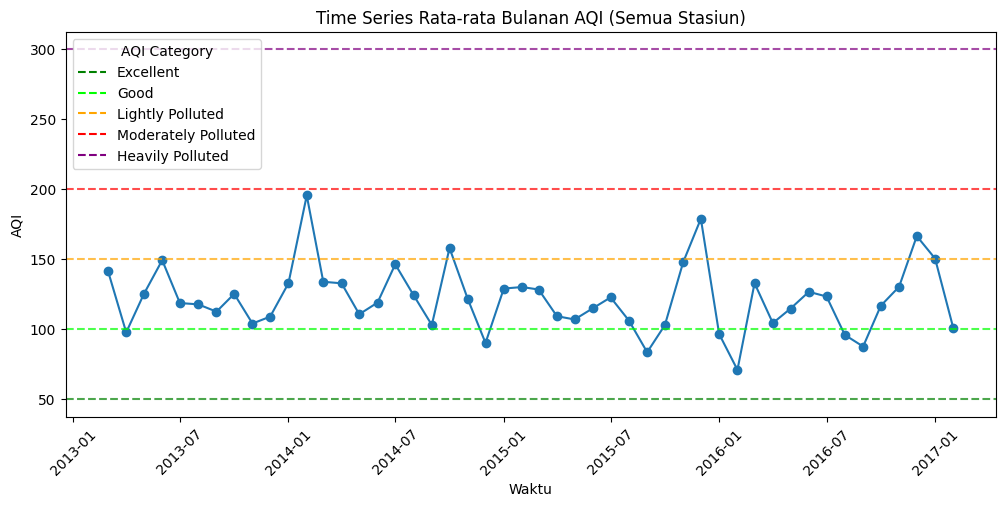

In [101]:
aqi_levels = [
    (50, "Excellent"),
    (100, "Good"),
    (150, "Lightly Polluted"),
    (200, "Moderately Polluted"),
    (300, "Heavily Polluted"),
]
colors = ['green', 'lime', 'orange', 'red', 'purple']

plt.figure(figsize=(12, 5))
plt.plot(df_monthly_all['year_month'], df_monthly_all['AQI'], marker='o')

# garis horizontal
for i, (level, label) in enumerate(aqi_levels):
    plt.axhline(y=level, linestyle='--', color=colors[i], alpha=0.7)

legend_lines = [
    Line2D([0], [0], color=colors[i], lw=1.5, linestyle='--', label=label)
    for i, (_, label) in enumerate(aqi_levels)
]
plt.legend(handles=legend_lines, title="AQI Category", loc='upper left')

# label & style
plt.title("Time Series Rata-rata Bulanan AQI (Semua Stasiun)")
plt.xlabel("Waktu")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

**Insights:**
- Nilai AQI fluktuatif sepanjang periode pengamatan.
- Secara keseluruhan, kualitas udara di Beijing selama 2013-2017 berada pada level `Lightly Poluted`.

#### Binning

Untuk melihat proporsi masing-masing kategori dalam level bulanan dan tahunan, dilakukan binning AQI Category berdasarkan China AQI Level.

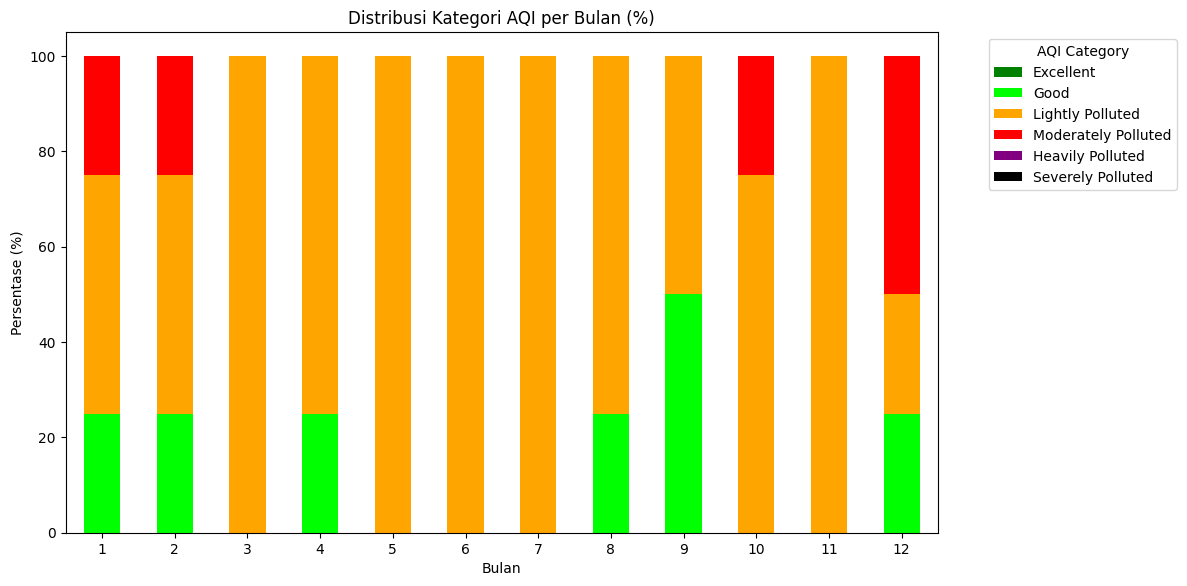

In [102]:
bins = [0, 50, 100, 150, 200, 300, float('inf')]

labels = [
    'Excellent',
    'Good',
    'Lightly Polluted',
    'Moderately Polluted',
    'Heavily Polluted',
    'Severely Polluted'
]

df_monthly_all['AQI_cat'] = pd.cut(
    df_monthly_all['AQI'],
    bins=bins,
    labels=labels,
    right=True
)

df_monthly_all['year'] = df_monthly_all['year_month'].dt.year
df_monthly_all['month'] = df_monthly_all['year_month'].dt.month

monthly_dist = pd.crosstab(
    df_monthly_all['month'],
    df_monthly_all['AQI_cat'],
    normalize='index'
) * 100

category_order = [
    'Excellent', 'Good', 'Lightly Polluted',
    'Moderately Polluted', 'Heavily Polluted', 'Severely Polluted'
]
monthly_dist = monthly_dist.reindex(columns=category_order, fill_value=0)

# plot
monthly_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['green', 'lime', 'orange', 'red', 'purple', 'black']
)

plt.title("Distribusi Kategori AQI per Bulan (%)")
plt.xlabel("Bulan")
plt.ylabel("Persentase (%)")
plt.legend(title="AQI Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

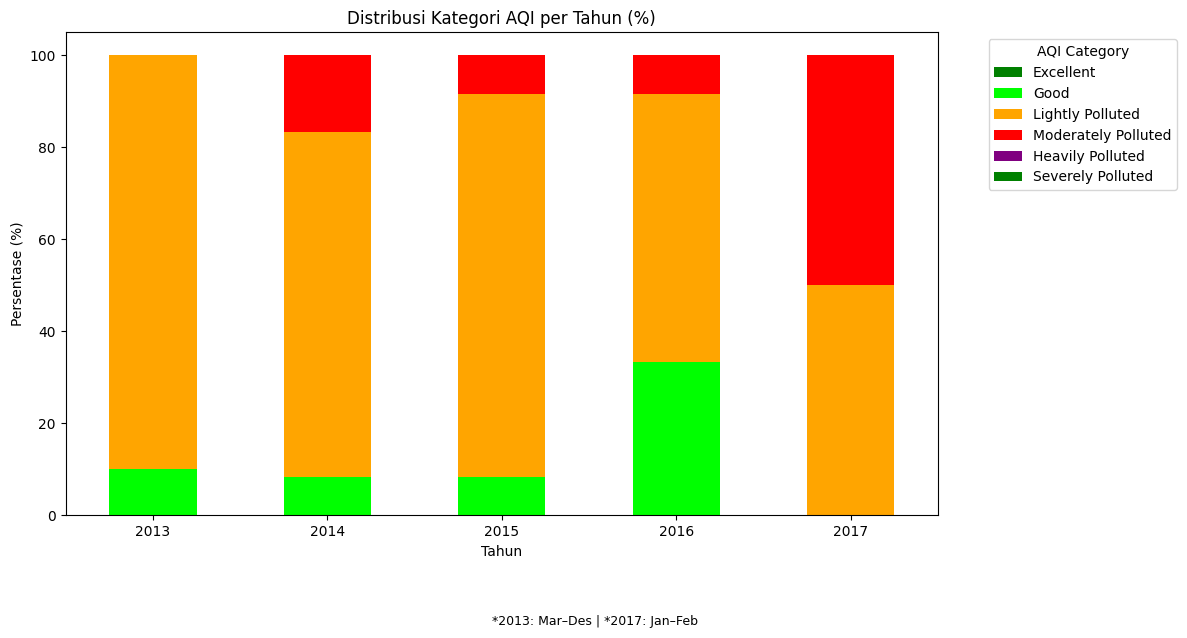

In [103]:
yearly_dist = pd.crosstab(
    df_monthly_all['year'],
    df_monthly_all['AQI_cat'],
    normalize='index'
) * 100

yearly_dist = yearly_dist.reindex(columns=category_order, fill_value=0)

yearly_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['green', 'lime', 'orange', 'red', 'purple']
)

plt.title("Distribusi Kategori AQI per Tahun (%)")
plt.xlabel("Tahun")
plt.ylabel("Persentase (%)")
plt.legend(title="AQI Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.xticks(rotation=0)
plt.figtext(
    0.5, -0.05,
    "*2013: Mar–Des | *2017: Jan–Feb",
    ha='center',
    fontsize=9
)

plt.show()

**Insights:**
- Proporsi `Lightly Poluted` mendominasi di sepanjang bulan pengamatan, menunjukkan bahwa kualitas udara di Beijing secara bulanan selama 2013-2017 cukup berpolusi. Hal tersebut juga berlaku untuk level tahunan yang berarti **Beijing secara konsisten berada di kategori tidak sehat.**
- Proporsi pada 2016 sedikit berbeda dari tahun-tahun lainnya, di mana kategori AQI `Good` jauh lebih tinggi dari tahun lain.

In [104]:
df_monthly_all.to_csv("data/df_monthly_all.csv", index=False)

### Pertanyaan 2: Apakah ada perbedaan kualitas udara antarstasiun yang mencolok?

In [105]:
polutan_aqi_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'AQI']
df_monthly_station = (
    df_agregasi.groupby(['station', 'year_month'])[polutan_aqi_cols]
    .mean()
    .reset_index()
)

df_monthly_station['AQI_cat'] = pd.cut(
    df_monthly_station['AQI'],
    bins=bins,
    labels=labels,
    right=True
)
df_monthly_station['year_month'] = df_monthly_station['year_month'].dt.to_timestamp()

# loop tiap stasiun
stations = df_monthly_station['station'].unique()
df_monthly_station.head()

,station,year_month,PM2.5,PM10,SO2,NO2,CO,O3,AQI,AQI_cat
0,Aotizhongxin,2013-03-01,110.092742,144.622984,44.945068,74.817409,1477.730511,68.163844,147.802299,Lightly Polluted
1,Aotizhongxin,2013-04-01,62.751389,108.204167,24.796646,53.501374,910.012500,81.854357,98.304255,Good
2,Aotizhongxin,2013-05-01,85.394489,140.778226,30.442204,61.016129,944.528226,141.857077,127.698541,Lightly Polluted
3,Aotizhongxin,2013-06-01,106.203472,128.716667,14.627276,72.798322,1295.164583,139.317902,155.449192,Moderately Polluted
4,Aotizhongxin,2013-07-01,68.911290,85.271505,9.285232,55.105382,820.551747,140.836432,117.242464,Lightly Polluted


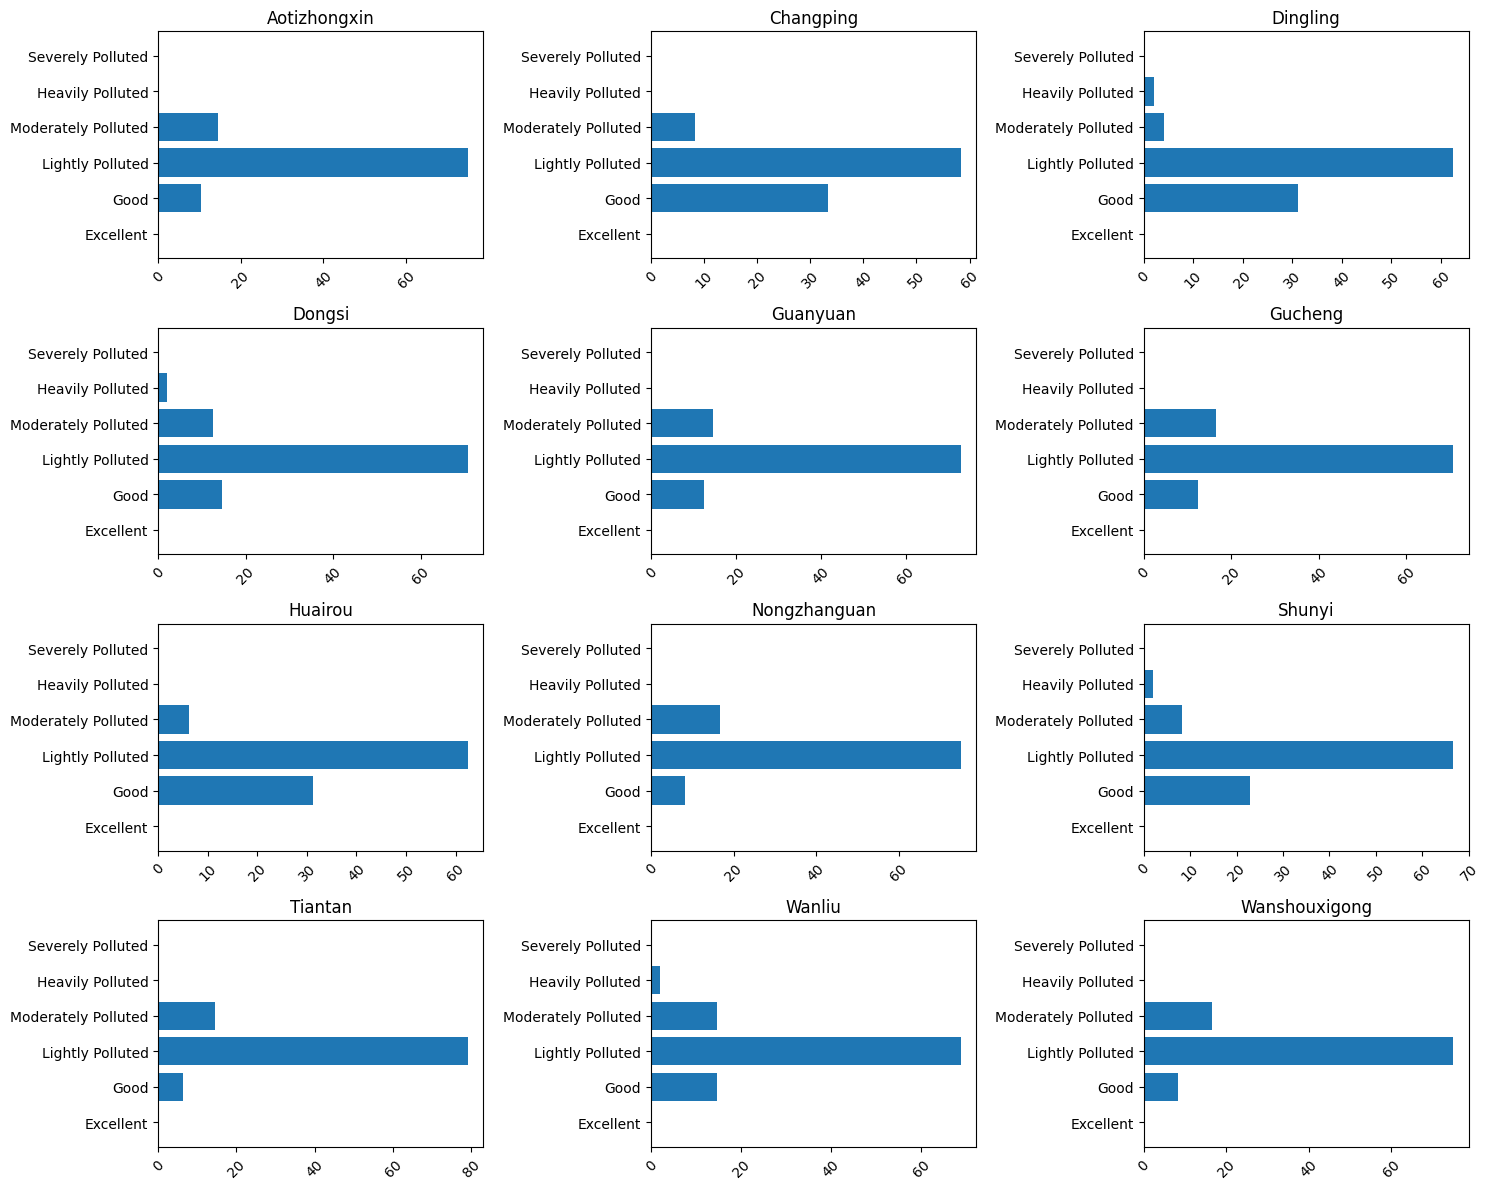

In [106]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, st in enumerate(stations):
    df_st = df_monthly_station[df_monthly_station['station'] == st]
    
    dist = df_st['AQI_cat'].value_counts(normalize=True) * 100
    dist = dist.reindex(category_order, fill_value=0)
    
    axes[i].barh(dist.index, dist.values)
    axes[i].set_title(st)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

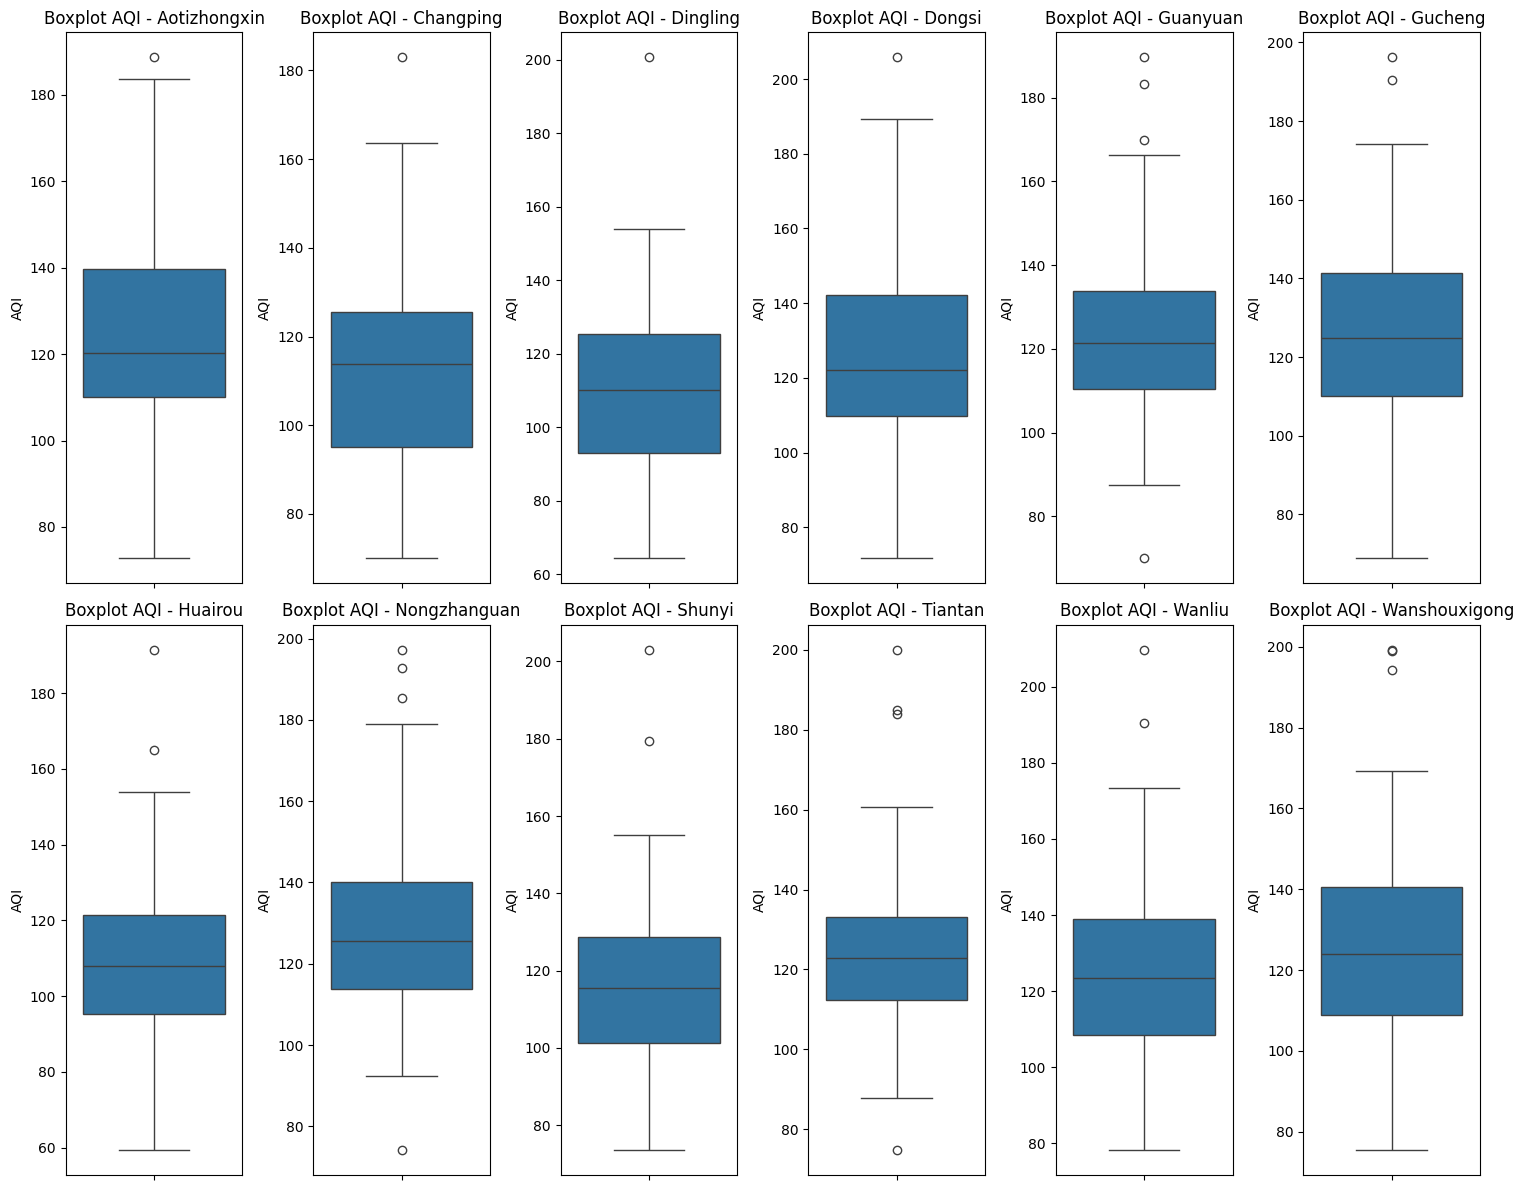

In [107]:
fig, axes = plt.subplots(2, 6, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, st in enumerate(stations):
    df_st = df_monthly_station[df_monthly_station['station'] == st]
    sns.boxplot(
        y=df_st['AQI'],
        ax=axes[i]
        #color='skyblue'
    )
    axes[i].set_title(f'Boxplot AQI - {st}')
    axes[i].set_ylabel('AQI')

plt.tight_layout()
plt.show()

#### Analisis Lanjutan (Opsional): Geospatial Analysis

In [108]:
station_coords = {
    'Aotizhongxin': (39.982, 116.397),
    'Changping': (40.217, 116.231),
    'Dingling': (40.292, 116.220),
    'Dongsi': (39.929, 116.417),
    'Guanyuan': (39.933, 116.339),
    'Gucheng': (39.914, 116.184),
    'Huairou': (40.357, 116.628),
    'Nongzhanguan': (39.937, 116.461),
    'Shunyi': (40.127, 116.655),
    'Tiantan': (39.886, 116.407),
    'Wanliu': (39.987, 116.306),
    'Wanshouxigong': (39.878, 116.352)
}

df_map = df_monthly_station.groupby('station')['AQI'].mean().reset_index()

df_map['lat'] = df_map['station'].map(lambda x: station_coords[x][0])
df_map['lon'] = df_map['station'].map(lambda x: station_coords[x][1])

# Center di Beijing
m = folium.Map(location=[39.9, 116.4], zoom_start=10)

def get_color(aqi):
    for i, (threshold, _) in enumerate(aqi_levels):
        if aqi <= threshold:
            return colors[i]
    return 'black'

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=10,
        popup=f"{row['station']}<br>Avg AQI: {row['AQI']:.2f}",
        color=get_color(row['AQI']),
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

legend_html = """
{% macro html(this, kwargs) %}
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000; background-color:white;
     padding: 10px; border-radius: 8px; font-size: 13px;">
  <b>AQI Category</b><br>
  <i style="background:green;width:12px;height:12px;display:inline-block"></i> Excellent (≤50)<br>
  <i style="background:lime;width:12px;height:12px;display:inline-block"></i> Good (≤100)<br>
  <i style="background:orange;width:12px;height:12px;display:inline-block"></i> Lightly Polluted (≤150)<br>
  <i style="background:red;width:12px;height:12px;display:inline-block"></i> Moderately Polluted (≤200)<br>
  <i style="background:purple;width:12px;height:12px;display:inline-block"></i> Heavily Polluted (≤300)<br>
  <i style="background:darkred;width:12px;height:12px;display:inline-block"></i> Severely Polluted (>300)
</div>
{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(legend_html)
m.get_root().add_child(macro)
m

**Insight:**
- Pada barchart, semua stasiun didominasi kategori kualitas udara `Lightly Polluted`.
- Pada boxplot, ke dua belas stasiun menunjukkan pola yang sangat mirip dengan median AQI berkisar di 110-130, yang termasuk `Lightly Polluted`. Tidak ada perbedaan signifikan antara stasiun. Pola lain yang terlihat yaitu hampir semua stasiun memiliki outlier di atas, menunjukkan ada episode polusi ekstrem sesekali di semua lokasi.
- Analisis geospatial menunjukkan bahwa semua stasiun memiliki kategori kualitas udara `Lightly Polluted`.
- Oleh karena itu, dapat disimpulkan bahwa **tidak ada perbedaan kualitas udara antarstasiun** yang mencolok.

In [109]:
df_monthly_station.to_csv("data/df_monthly_station.csv", index=False)

### Pertanyaan 3: Apakah kondisi cuaca tertentu berkaitan dengan tinggi-rendahnya polutan pada level harian?

Untuk menjawab pertanyaan tersebut, diperlukan dataFrame yang mencakup rata-rata harian semua stasiun untuk semua variabel polutan dan variabel cuaca.

In [110]:
polutan_cols

['PM2.5', 'PM10', 'SO2', 'NO2', 'CO']

In [111]:
cuaca_cols

['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

In [112]:
polutan_cols.append('O3')

df_daily_all = (
    df_agregasi.groupby('date')[polutan_cols + cuaca_cols]
    .mean()
    .reset_index()
)
df_daily_all.head()

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013-03-01,7.326389,12.203125,9.182292,18.824653,404.861111,78.770833,1.173958,1026.569792,-20.148611,0.0,2.917708
1,2013-03-02,31.475694,40.506944,31.757878,56.303763,939.715278,59.322917,0.260417,1026.552778,-16.271875,0.0,1.145139
2,2013-03-03,79.291667,111.104167,49.286458,75.661458,1771.142361,51.270833,5.257292,1014.215278,-12.325347,0.0,1.463194
3,2013-03-04,21.768569,40.359375,18.818692,40.877151,726.340278,79.593750,9.610764,1017.263194,-12.773264,0.0,2.227083
4,2013-03-05,125.352959,159.236111,70.756944,103.337674,2021.434028,90.666667,6.630556,1010.551389,-7.916319,0.0,0.992014


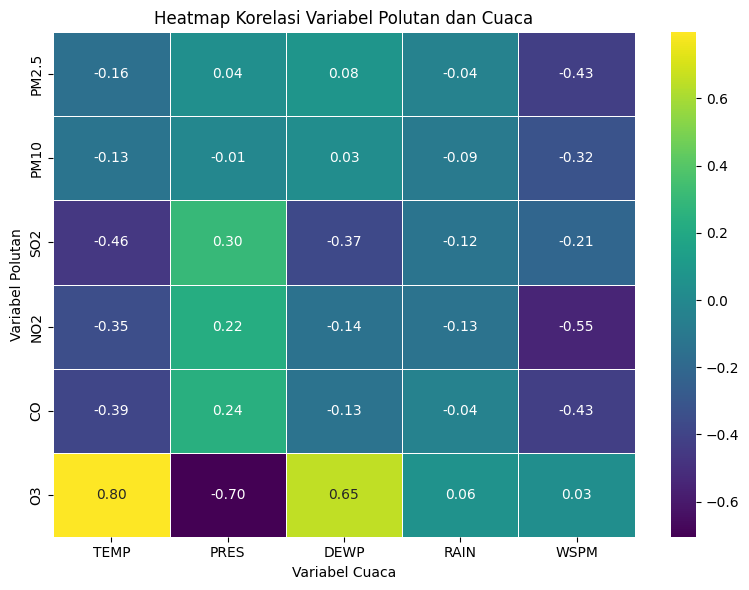

In [113]:
correlation = df_daily_all.corr().loc[polutan_cols, cuaca_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidth=0.5,
)

plt.title("Heatmap Korelasi Variabel Polutan dan Cuaca")
plt.xlabel("Variabel Cuaca")
plt.ylabel("Variabel Polutan")
plt.tight_layout()
plt.show()

**Insights**:
- `TEMP`: Variabel O3 memiliki korelasi positif kuat dengan variabel TEMP (temperatur) atau suhu, yaitu 0.80, di mana angka ini merupakan korelasi tertinggi. Sementara itu, SO2, NO2, dan CO memiliki korelasi negatif cukup kuat dengan TEMP. Hal ini berarti saat suhu tinggi (misalnya saat musim panas),  SO2, NO2, dan CO cenderung turun, berkebalikan dengan O3 yang malah naik drastis. Variabel partikel seperti PM2.5 dan PM10 memiliki korelasi negatif lemah terhadap TEMP.
- `PRES`: Variabel O3 berkorelasi negatif kuat dengan nilai -0.70. Polutan lain seperti SO2, NO2, dan CO berkorelasi positif cukup kuat. Sementara PM2.5 dan PM10 hampir tidak berkorelasi dengan PRES (tekanan udara).
- `DEWP`: Variabel O3 berkorelasi positif kuat dengan nilai 0.65, hal ini karena titik embun (DEWP/Dewpoint) berkaitan erat dengan suhu tinggi yang mendorong pembentukan O3. Sementara itu, SO2 berkorelasi negatif cukup kuat dengan nilai -0.37. Variabel polutan lain memiliki korelasi lemah dengan DEWP.
- `RAIN`: Semua variabel polutan berkorelasi lemah dengan rentang -0.13 sampai 0.06.
- `WSPM`: Variabel NO2 memiliki korelasi negatif cukup kuat dengan WSPM (kecepatan angin), yaitu -0.55 yang merupakan korelasi paling kuat di antara variabel polutan lainnya. Sementara itu, variabel CO dan PM2.5 juga memiliki korelasi negatif cukup kuat dengan WSMP. Variabel O3 memiliki korelasi sangat lemah, yaitu 0.03.
- Secara keseluruhan, variabel O3 adalah variabel polutan yang memiliki korelasi paling kuat terhadap variabel-variabel cuaca, terutama terhadap `TEMP` (0.80), `PRES` (-0.70), `DEWP` (0.65).

### Pertanyaan 4: Apakah ada pola musiman pada variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)?

Untuk menjawab pertanyaan tersebut, dapat menggunakan dataFrame yang telah dibuat di pertanyaan 3.

dan menambahkan fitur season menggunakan mapping. Kemudian, variabel-variabel polutan divisualisasikan dengan boxplot berdasarkan season.

Fitur season mengacu pada musim di Tiongkok, yaitu:
1. spring -> Maret, April, Mei
2. summer -> Juni, Juli, Agustus
3. autumn -> September, Oktober, November
4. winter -> Desember, Januari, Februari

In [114]:
season_mapping = {
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    12: 'Winter', 1: 'Winter', 2: 'Winter'
}

df_daily_all['month'] = df_daily_all['date'].dt.month
df_daily_all["season"] = df_daily_all["month"].map(season_mapping)
df_daily_all.sample(7)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,month,season
135,2013-07-14,101.760627,95.232639,10.479597,27.997548,1129.401960,172.913558,26.753125,1001.408681,21.871181,0.502083,1.466667,7,Summer
875,2015-07-24,53.024306,69.593750,3.442708,41.592014,868.229167,167.791667,26.441319,995.925000,20.218750,0.000000,1.323958,7,Summer
1060,2016-01-25,26.494792,45.359375,15.977431,39.571181,788.020833,52.552083,-3.075000,1024.531944,-23.161111,0.000000,2.942708,1,Winter
585,2014-10-07,118.201389,155.034722,10.600694,82.291667,1156.250000,83.833333,14.246875,1013.543750,8.430208,0.000000,0.879167,10,Autumn
211,2013-09-28,229.163194,257.517361,15.077167,73.148651,1526.822917,115.725938,15.951042,1005.350347,12.214931,0.000000,0.895139,9,Autumn
31,2013-04-01,101.177083,123.500000,24.216247,44.294496,1353.852431,95.663826,10.494444,1011.271528,-4.939236,0.000000,2.901042,4,Spring
625,2014-11-16,76.715278,101.663194,16.843750,56.340278,1606.597222,52.604167,6.457639,1019.569444,-5.260417,0.000000,2.068403,11,Autumn


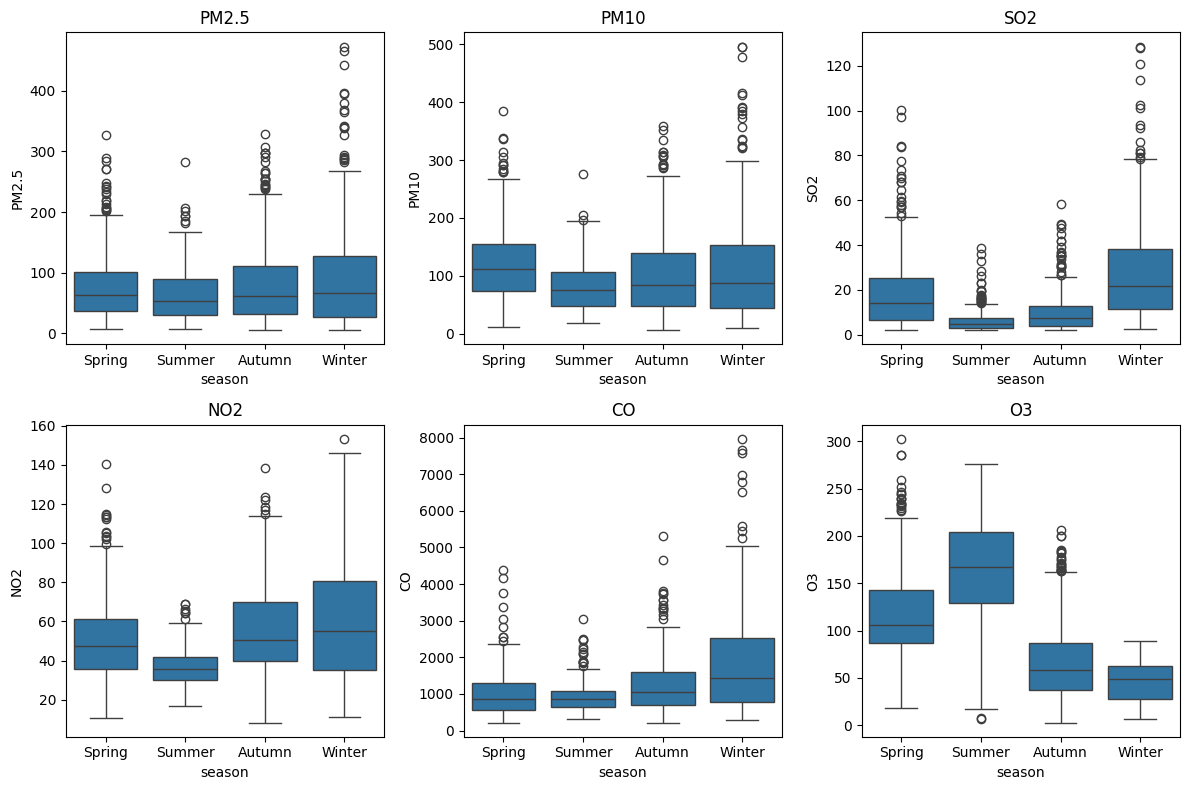

In [115]:
pfig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, pol in enumerate(polutan_cols):
    sns.boxplot(
        data=df_daily_all,
        x='season',
        y=pol,
        ax=axes[i]
    )
    axes[i].set_title(pol)

plt.tight_layout()
plt.show()

Untuk melihat pola musiman dengan lebih jelas, dibuat time series plot pada level bulanan untuk rata-rata semua stasiun dengan menggunakan data dari pertanyaan 1, yaitu `df_monthly_all`.

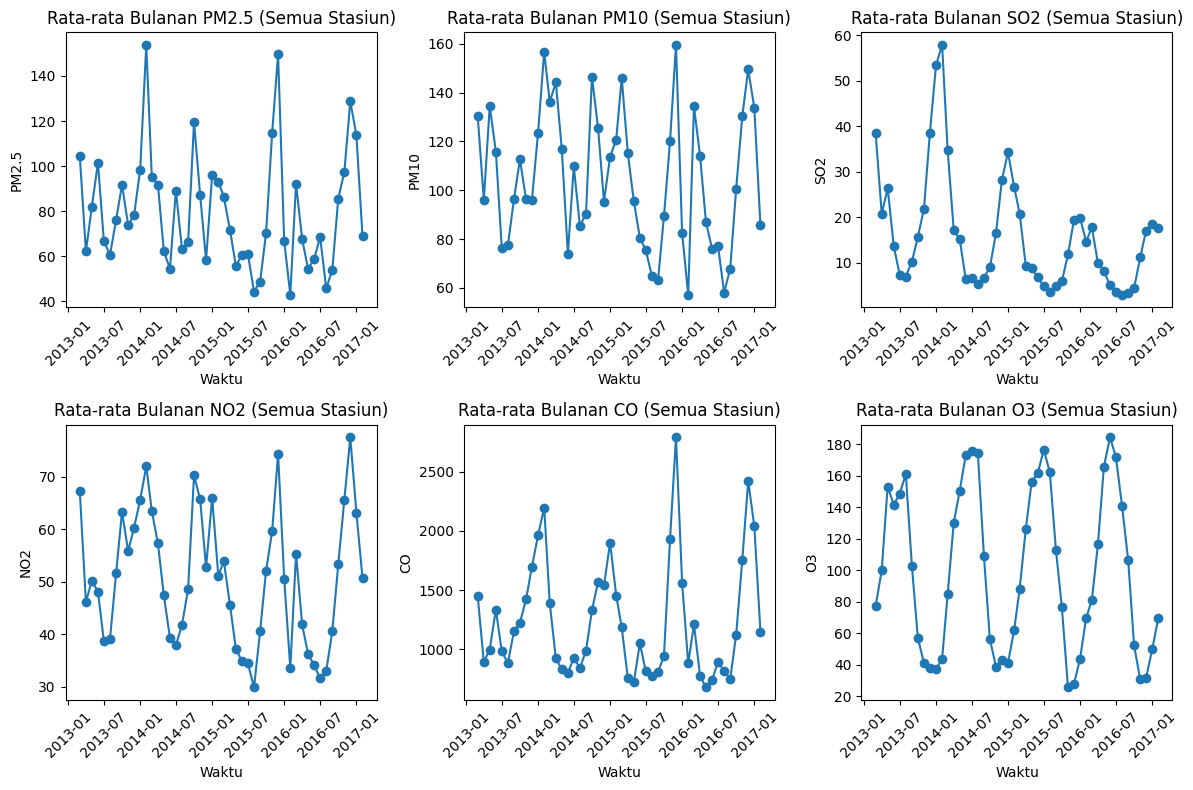

In [116]:
pfig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, pol in enumerate(polutan_cols):
    axes[i].plot(df_monthly_all['year_month'], df_monthly_all[pol], marker='o')

    axes[i].set_title(f"Rata-rata Bulanan {pol} (Semua Stasiun)")
    axes[i].set_xlabel("Waktu")
    axes[i].set_ylabel(pol)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights**:
- Variabel partikel (PM2.5 dan PM10) menunjukkan pola yang sangat mirip. Pada musim dingin (winter), keduanya memiliki nilai outlier yang banyak dan IQR yang tinggi, diikuti dengan spring dan autumn. Sementara nilai outlier pada summer tidak banyak. Hal ini sejalan dengan hasil korelasi PM2.5 dan PM10 yang negatif lemah terhadap variabel suhu.
- Pola musiman paling terlihat pada variabel SO2. Nilai media SO2 saat winter hampir 3x lipat dibandingkan saat summer. Bahkan, nilai SO2 saat summer hampir mendekati nol secara median.
- NO2 juga menunjukkan pola musiman yang cukup kuat walau tidak sedrastis SO2. Median winter dan autum lebih tinggi dari spring dan summer.
- CO memiliki skala yang jauh lebih besar dibandingkan polutan lain, yaitu sampai 8000 (ug/m^3). Pola musiman yang terlihat mirip seperti pada PM2.5, yaitu nilai outlier tinggi saat winter, dan rendah saat summer.
- Variabel O3 memiliki pola musiman yang berkebalikan dengan polutan lainnya. Nilai O3 saat summer merupakan yang tertinggi secara media dibandingkan musim lain, sementara winter yang terendah. Ini sesuai dengan hasil korelasi di mana arah korelasi O3 sering berkebalikan dengan variabel polutan lainnya.
- Pada time series plot, pola musiman terlihat jelas pada SO2 dan O3, dan agak terlihat pada NO2 dan CO. Sementara variabel PM2.5 dan PM10 tidak menunjukkan pola tertentu pada plot time series.

In [117]:
df_daily_all.to_csv("data/df_daily_all.csv", index=False)

## Conclusion

1. Bagaimana kondisi kualitas udara di Beijing selama 2013-2017 secara keseluruhan?
Proporsi `Lightly Poluted` mendominasi di sepanjang bulan pengamatan, menunjukkan bahwa kualitas udara di Beijing secara bulanan selama 2013-2017 cukup berpolusi. Hal tersebut juga berlaku untuk level tahunan yang berarti **Beijing secara konsisten berada di kategori tidak sehat.**

2. Apakah ada perbedaan kualitas udara antarstasiun yang mencolok?
Visualisasi dengan barchart dan boxplot, serta analisis geospatial menunjukkan bahwa **tidak ada perbedaan kualitas udara yang signfikan antarstasiun di Beijing.**

3. Apakah kondisi cuaca dan musim tertentu berkaitan dengan tinggi-rendahnya polutan?
Beberapa variabel polutan memiliki korelasi dengan kondisi cuaca. Di antaranya, **variabel `O3` secara keseluruhan merupakan variabel polutan yang memiliki korelasi paling kuat terhadap variabel-variabel cuaca**,  terutama terhadap `TEMP` (0.80), `PRES` (-0.70), `DEWP` (0.65).

4. Apakah ada pola musiman pada variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)?
Pada boxplot, **pola musiman pada level harian paling terlihat pada variabel SO2 dan O3**, diikuti dengan NO2 dan CO. Variabel partikel (PM2.5 dan PM10) memiliki pola yang cukup mirip. Sementara pada time series plot, **pola musiman pada level bulanan terlihat jelas pada SO2 dan O3**, dan agak terlihat pada NO2 dan CO. Sementara variabel PM2.5 dan PM10 tidak menunjukkan pola tertentu pada plot time series.